File 3 → visualization_business_insights.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "preprocessed_demand_forecasting_data.csv",
    parse_dates=['Date']
)

In [3]:
print(df.shape)
print(df.head())

(75860, 25)
        Date Store ID Product ID     Category Region  Inventory Level  Price  \
0 2022-01-02     S003      P0001         Toys   East               73  15.76   
1 2022-01-02     S004      P0001    Groceries   West              130  12.67   
2 2022-01-02     S005      P0001    Groceries  North              107  11.70   
3 2022-01-03     S001      P0001  Electronics  North              274  68.55   
4 2022-01-03     S002      P0001    Groceries  South                0  84.32   

   Discount Weather Condition  Promotion  ...  month  year  weekday  \
0         5            Cloudy          0  ...      1  2022        6   
1        10             Sunny          0  ...      1  2022        6   
2         0             Snowy          0  ...      1  2022        6   
3        15             Snowy          1  ...      1  2022        0   
4        20            Cloudy          1  ...      1  2022        0   

   weekofyear  is_weekend  Discounted Price  lag_1  lag_7  rolling_mean_7  \
0  

SECTION 2 - Encoding

In [4]:
from sklearn.preprocessing import LabelEncoder

# Target and Features

target = "Demand"

features = [col for col in df.columns if col not in ["Date", "Demand"]]

X = df[features]
y = df[target]

In [5]:
# Copying Dataset

X_encoded = X.copy()

# Label Encoding

label_cols = ["Product ID", "Store ID"]

label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# One-Hot Encoding

onehot_cols = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "discount_bin"
]

X_encoded = pd.get_dummies(
    X_encoded,
    columns=onehot_cols,
    drop_first=True
)

# Convert bool to int

bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

# Clean Column Names

X_encoded.columns = X_encoded.columns.str.replace('[', '', regex=False)
X_encoded.columns = X_encoded.columns.str.replace(']', '', regex=False)
X_encoded.columns = X_encoded.columns.str.replace('<', '', regex=False)


In [6]:
print(X_encoded.shape)
print(X_encoded.head())

(75860, 33)
   Store ID  Product ID  Inventory Level  Price  Discount  Promotion  \
0         2           0               73  15.76         5          0   
1         3           0              130  12.67        10          0   
2         4           0              107  11.70         0          0   
3         0           0              274  68.55        15          1   
4         1           0                0  84.32        20          1   

   Competitor Pricing  Epidemic  day  month  ...  Region_South  Region_West  \
0               16.81         0    2      1  ...             0            0   
1               11.95         0    2      1  ...             0            1   
2               10.06         0    2      1  ...             0            0   
3               80.73         0    3      1  ...             0            0   
4               92.33         0    3      1  ...             1            0   

   Weather Condition_Rainy  Weather Condition_Snowy  Weather Condition_Sunny  \


SECTION 3 - Time-Aware Split

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [8]:
# Time-Aware Split

split_date = "2023-09-01"

# Train set
X_train = X_encoded[df["Date"] < split_date]
y_train = y[df["Date"] < split_date]

# Test set
X_test = X_encoded[df["Date"] >= split_date]
y_test = y[df["Date"] >= split_date]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)



Training shape: (60660, 33)
Testing shape: (15200, 33)


In [9]:
# Final Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nFinal Random Forest Results")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))


Final Random Forest Results
MAE : 17.43
RMSE: 24.19


SECTION 4 - Feature Importance

               Feature  Importance
17      rolling_mean_7    0.334044
3                Price    0.113097
1           Product ID    0.052277
5            Promotion    0.051174
19  Category_Furniture    0.042763
6   Competitor Pricing    0.042752
20  Category_Groceries    0.041347
15               lag_1    0.041036
2      Inventory Level    0.036019
16               lag_7    0.032914


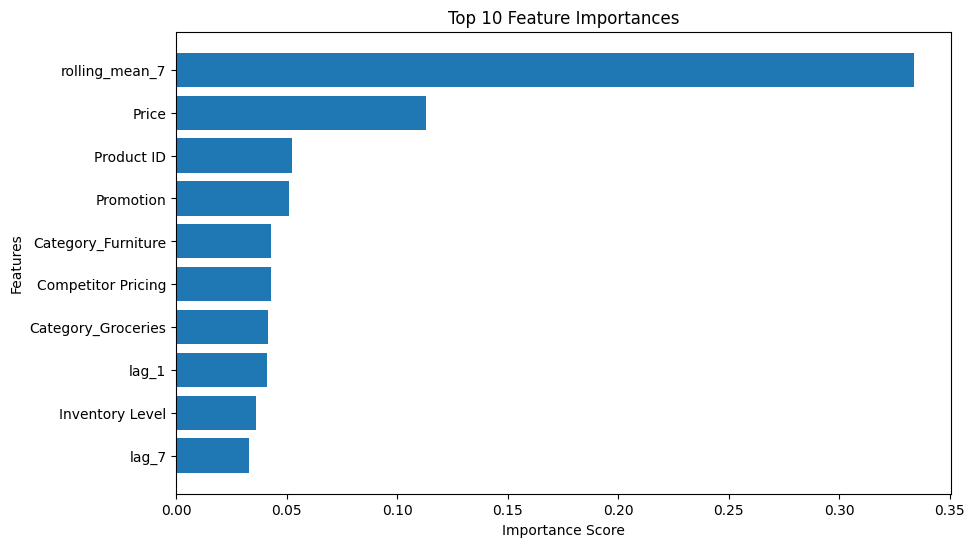

In [10]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 features
print(importance_df.head(10))

# Visualization:

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'].head(10),
    importance_df['Importance'].head(10)
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

SECTION 5 - Actual vs Predicted

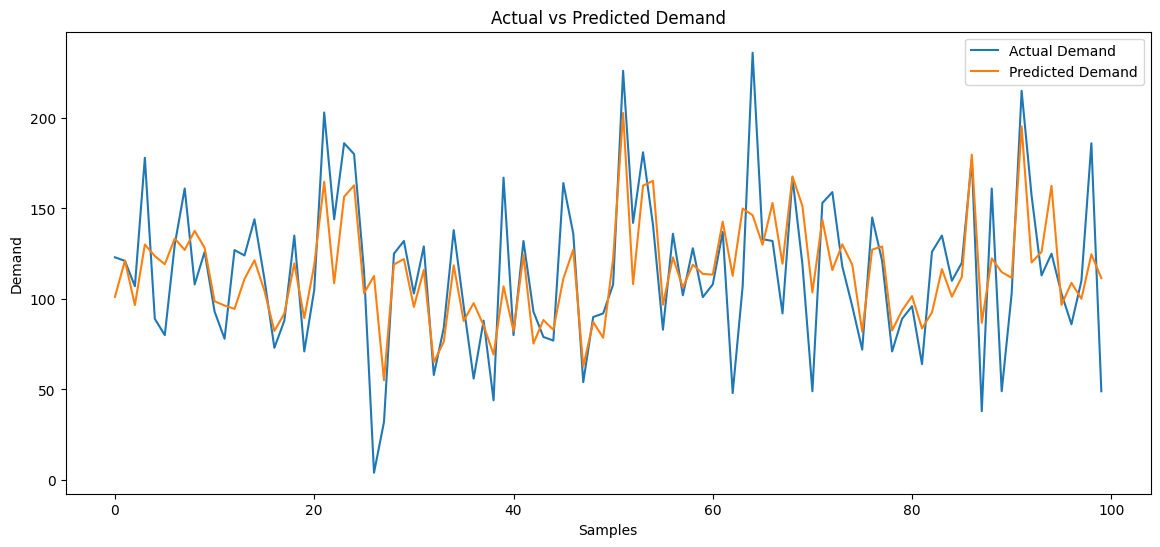

In [11]:

results_df = pd.DataFrame({
    'Actual Demand': y_test.values,
    'Predicted Demand': y_pred_rf
})

# Plot first 100 predictions
plt.figure(figsize=(14,6))

plt.plot(
    results_df['Actual Demand'].values[:100],
    label='Actual Demand'
)

plt.plot(
    results_df['Predicted Demand'].values[:100],
    label='Predicted Demand'
)

plt.title("Actual vs Predicted Demand")
plt.xlabel("Samples")
plt.ylabel("Demand")

plt.legend()

plt.show()

SECTION 6 - Residual Analysis

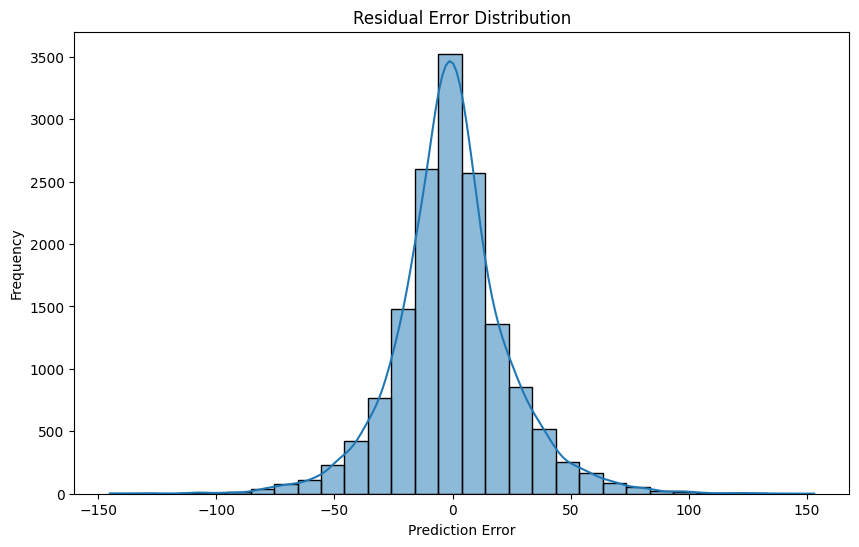

In [12]:
# Residual Analysis:

residuals = y_test - y_pred_rf

# Plot residual distribution
plt.figure(figsize=(10,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

SECTION 7 — Stock Risk Classification

Stock Status
Overstock Risk    12358
Balanced Stock     1800
Low Stock Risk     1042
Name: count, dtype: int64


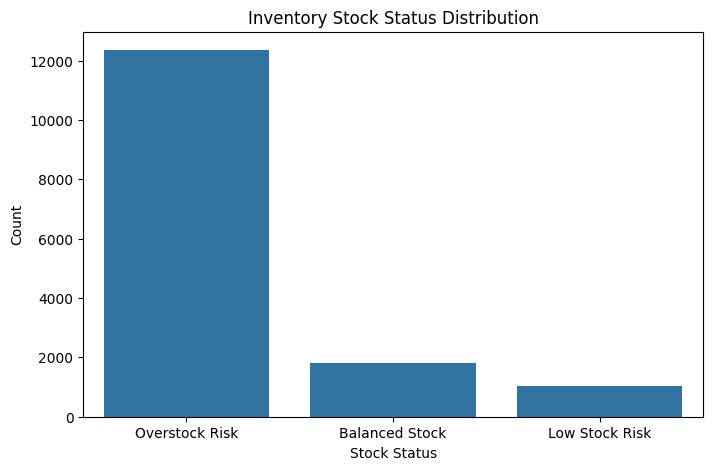

In [13]:
# Inventory Risk Analysis:

business_df = X_test.copy()

# Add actual inventory
business_df['Inventory Level'] = X_test['Inventory Level']

# Add predictions
business_df['Predicted Demand'] = y_pred_rf

# Stock Coverage Ratio:

business_df['stock_ratio'] = (
    business_df['Inventory Level'] /
    business_df['Predicted Demand']
)

# Stock Status Classification:

def classify_stock(ratio):

    if ratio < 0.8:
        return "Low Stock Risk"

    elif ratio <= 1.2:
        return "Balanced Stock"

    else:
        return "Overstock Risk"

business_df['Stock Status'] = business_df['stock_ratio'].apply(classify_stock)

# Status Counts:

print(
    business_df['Stock Status']
    .value_counts()
)

# Visualization:

plt.figure(figsize=(8,5))

sns.countplot(
    data=business_df,
    x='Stock Status'
)

plt.title("Inventory Stock Status Distribution")

plt.xlabel("Stock Status")
plt.ylabel("Count")

plt.show()

SECTION 8 — Reorder Recommendation System

In [14]:
business_df = X_test.copy()

#Business Info

business_df['Product ID'] = (
    df.loc[X_test.index, 'Product ID']
)

business_df['Category'] = (
    df.loc[X_test.index, 'Category']
)

business_df['Region'] = (
    df.loc[X_test.index, 'Region']
)

#Inventory + Predictions

business_df['Inventory Level'] = X_test['Inventory Level']

business_df['Predicted Demand'] = y_pred_rf

# Safety buffer based on MAE
safety_buffer = 20

# Required Stock Calculation

business_df['Required Stock'] = (
    business_df['Predicted Demand']
    + safety_buffer
)

# Reorder Quantity

business_df['Reorder Quantity'] = (
    business_df['Required Stock']
    - business_df['Inventory Level']
)

# No negative reorder values
business_df['Reorder Quantity'] = (
    business_df['Reorder Quantity']
    .clip(lower=0)
)

# Round reorder quantity
business_df['Reorder Quantity'] = (
    business_df['Reorder Quantity']
    .round()
    .astype(int)
)

# Stock Coverage Ratio:

business_df['stock_ratio'] = (
    business_df['Inventory Level']
    / business_df['Predicted Demand']
)

# Stock Status Classification:

def classify_stock(ratio):

    if ratio < 0.8:
        return "Low Stock Risk"

    elif ratio <= 1.2:
        return "Balanced Stock"

    else:
        return "Overstock Risk"

business_df['Stock Status'] = (
    business_df['stock_ratio']
    .apply(classify_stock)
)

# Sample Results:

print(
    business_df[
        [
            'Product ID',
            'Category',
            'Region',
            'Inventory Level',
            'Predicted Demand',
            'Required Stock',
            'Reorder Quantity',
            'Stock Status'
        ]
    ].head(10)
)


     Product ID     Category Region  Inventory Level  Predicted Demand  \
3033      P0001  Electronics  North              252            101.16   
3034      P0001    Groceries  South              456            121.18   
3035      P0001         Toys   East              113             96.61   
3036      P0001    Groceries   West               74            130.09   
3037      P0001    Groceries  North              257            123.69   
3038      P0001  Electronics  North              133            119.17   
3039      P0001    Groceries  South              331            133.30   
3040      P0001         Toys   East              194            127.08   
3041      P0001    Groceries   West                0            137.60   
3042      P0001    Groceries  North              555            128.19   

      Required Stock  Reorder Quantity    Stock Status  
3033          121.16                 0  Overstock Risk  
3034          141.18                 0  Overstock Risk  
3035          

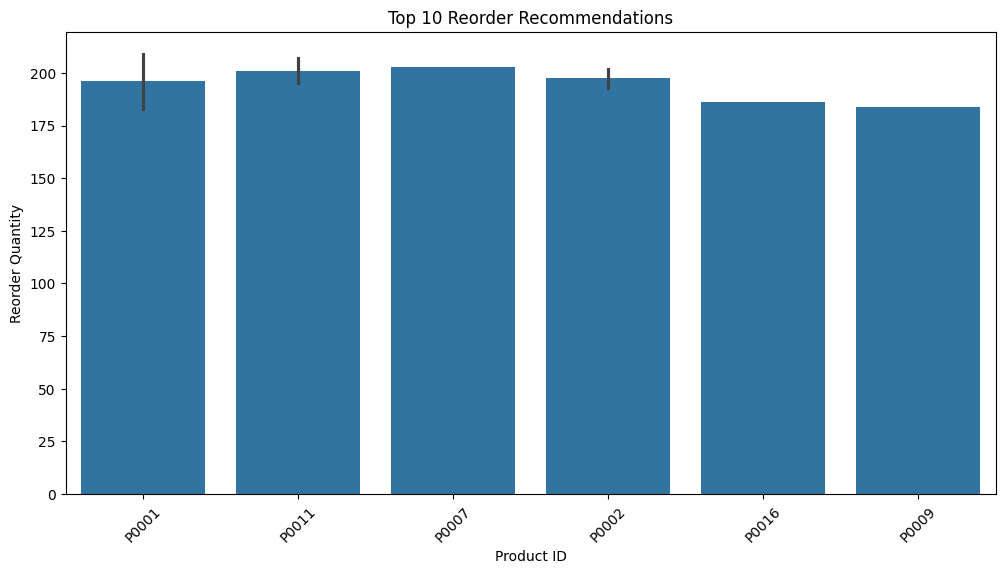

      Product ID   Category Region  Inventory Level  Predicted Demand  \
3312       P0001  Groceries  North                0            188.88   
41459      P0011  Groceries  South                0            186.84   
25950      P0007  Groceries  North               49            231.88   
7183       P0002  Groceries   East                0            182.12   
41009      P0011  Groceries  South                0            181.00   
41004      P0011  Groceries  South                0            175.22   
7104       P0002  Groceries   West                2            174.54   
60397      P0016       Toys  North                0            165.77   
33439      P0009  Groceries   East               48            212.13   
3497       P0001  Groceries  North                0            163.11   

       Required Stock  Reorder Quantity    Stock Status  
3312           208.88               209  Low Stock Risk  
41459          206.84               207  Low Stock Risk  
25950          251.88 

In [15]:
# Top Reorder Recommendations:

top_reorders = business_df.sort_values(
    by='Reorder Quantity',
    ascending=False
).head(10)


plt.figure(figsize=(12,6))

sns.barplot(
    data=top_reorders,
    x='Product ID',
    y='Reorder Quantity'
)

plt.title("Top 10 Reorder Recommendations")

plt.xlabel("Product ID")
plt.ylabel("Reorder Quantity")

plt.xticks(rotation=45)

plt.show()

#Top Reorder Table

print(
    top_reorders[
        [
            'Product ID',
            'Category',
            'Region',
            'Inventory Level',
            'Predicted Demand',
            'Required Stock',
            'Reorder Quantity',
            'Stock Status'
        ]
    ]
)

SECTION 9 

In [16]:
import joblib

joblib.dump(
    rf_model,
    "rf_model.pkl"
)


joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

joblib.dump(
    X_encoded.columns.tolist(),
    "feature_columns.pkl"
)

print("Model and encoders saved successfully.")

Model and encoders saved successfully.
